# Tests de UI
---

## Automatización Web

* Es una disciplina que utiliza software (bots o scripts) para realizar acciones, tareas y procesos predefinidos en un navegador web o aplicacion, **simulando el comportamiento de un usuario humano**
* **Objetivo principal**: reducir el esfuerzo manual, aumentar la velocidad de ejecución y mejorar la precisión en tareas repetitivas

## Metaaplicaciones de la Automatización Web

* **Automatizar procesos**: descargar datos, completar formularios, generación de backups, procesamientos de datos, etc.
* **Automatizar el testeo** (qa automation): validar que los datos ingresados (trámites a distancia TAD) persistan en la BD, validar movimientos financieros, etc.

## Aplicaciones Clave de la Automatización Web

1. **Pruebas de Software (QA)**: simulación del recorrido del usuario para garantizar la funcionalidad y compatibilidad de las aplicaciones web (pruebas de regreción)
2. **RPA (Robotic Process Automation)**: automatización de flujos de trabajo de negocio, como llenado de formularios o la transferencia de datos entre sistemas
3. **Web Scraping**: extraccion de datos especificos de sitios web para análisis o inteligencia competitiva
4. **Monitoreo y Alertas**: verificación periódica del estado de servicios y sitios web para detectar fallos o cambios de rendimiento
5. **Generación de Datos**: creación masiva y automatizada de cuentas o datos de prueba para inicializar entornos de desarrollo

## Funcionamiento de la Automatización Web

1. **Selección de Herramientas**:
    * lenguaje de programación (como Python o JavaScript)
    * framework de automatización (como [Selenium](https://selenium-python.readthedocs.io/) o Playwright)
1. **Acceso al Recurso Web**: el script utiliza el framework para lanzar y controlar un navegador (Chrome, Firefox, etc.), que puede ejecutarse en modo visible o en modo headless (sin interfaz gráfica)
1. **Localización de Elementos**: identificar los elementos de la página (botones, campos de texto, enlaces) mediante sus atributos únicos, como `ID`, `class` o `XPath`
1. **Simulación de Acciones**: una vez que el elemento es localizado, el script simula acciones del usuario:
    * __Clics__: simular la pulsación en botones o enlaces
    * __Entrada da Datos__: enviar cadenas de texto a campos de formulario
    * __Navegación__: instruir al navegador para ir a una nueva URL
1. **Validación y Reporte**: en el contexto de QA o RPA, el script verifica el resultado de la acción (por ejemplo, si la URL cambió o si apareció un mensaje de éxito) y reporta si el proceso fue exitoso

## Objetivos

* Desarrollar un programa
    * para mejorar la eficiencia (tiempos) operativa
    * que valide funcionalidades de una aplicación web

## Preparación del entorno

1. Crear repo en Git
2. Clonar repo
3. Crear entorno virtual
4. Activar entonro virtual
5. Instalación librerias: selenium

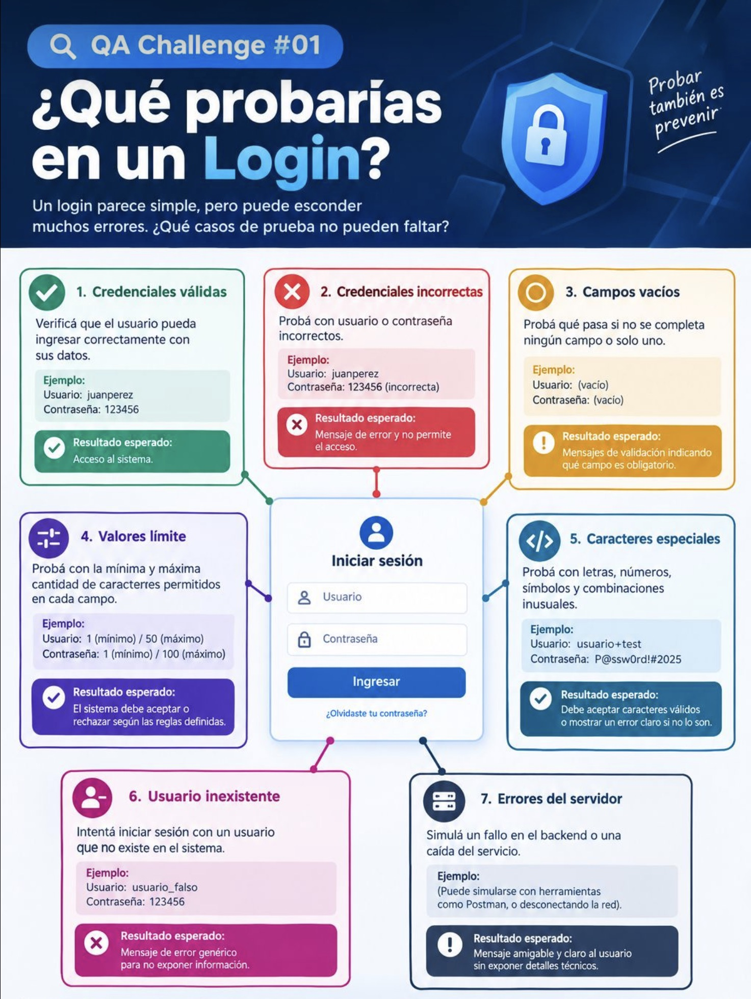

## Login en Herokuapp

Flujo:
1. Abrir un navegador e ingresar la URL: https://the-internet.herokuapp.com/login
2. Ingresar **tomsmith** en el cuadro de texto del Username
3. Ingresar **SuperSecretPassword!** en el cuadro de texto Password
4. Pulsar el botón **Login**
5. Validar que se haya ingresado a un área segura

In [4]:
from selenium import webdriver
from selenium.webdriver.common.by import By

# Abrir el navegador
driver = webdriver.Chrome()

# Navegar a una página web
driver.get('https://the-internet.herokuapp.com/login')

# Buscar elementos web y ejecutar acciones
driver.find_element(By.ID, 'username').send_keys('tomsmith')
driver.find_element(By.ID, 'password').send_keys('SuperSecretPassword!')
driver.find_element(By.TAG_NAME, 'button').click()

# Verificar (actual vs expected)
assert  driver.find_element(By.TAG_NAME, 'h2').text == 'Secure Area'

# Cerrar el navegador
driver.quit()

## Login en Saucedemo

### Happy path

In [7]:
from selenium import webdriver
from selenium.webdriver.common.by import By

driver = webdriver.Chrome()
driver.get('https://www.saucedemo.com/')
driver.find_element(By.ID, 'user-name').send_keys('standard_user')
driver.find_element(By.ID, 'password').send_keys('secret_sauce')
driver.find_element(By.ID, 'login-button').click()
assert driver.find_element(By.XPATH, "//div[@class='app_logo']").text == 'Swag Labs'
driver.quit()

### Unhappy path

In [11]:
from selenium import webdriver
from selenium.webdriver.common.by import By

driver = webdriver.Chrome()
driver.get('https://www.saucedemo.com/')
driver.find_element(By.ID, 'login-button').click()
assert driver.find_element(By.TAG_NAME, 'h3').text == 'Epic sadface: Username is required'
driver.quit()

### Integrado en una clase

In [29]:
%%file ui/test_login_saucedemo.py
import pytest
from selenium import webdriver
from selenium.webdriver.common.by import By

@pytest.mark.usefixtures('class_setup')
class TestLogin:

    @pytest.fixture
    def class_setup(self):
        self.driver = webdriver.Chrome()
        self.driver.get('https://www.saucedemo.com/')

    def test_login_correcto(self):
        self.driver.find_element(By.ID, 'user-name').send_keys('standard_user')
        self.driver.find_element(By.ID, 'password').send_keys('secret_sauce')
        self.driver.find_element(By.ID, 'login-button').click()
        assert self.driver.find_element(By.XPATH, "//div[@class='app_logo']").text == 'Swag Labs'
        self.driver.quit()

    def test_login_incorrecto_sin_user_sin_pass(self):
        self.driver.find_element(By.ID, 'login-button').click()
        assert self.driver.find_element(By.TAG_NAME, 'h3').text == 'Epic sadface: Username is required'
        self.driver.quit()

    def test_login_incorrecto_con_user_sin_pass(self):
        self.driver.find_element(By.ID, 'user-name').send_keys('standard_user')
        self.driver.find_element(By.ID, 'login-button').click()
        assert self.driver.find_element(By.TAG_NAME, 'h3').text == 'Epic sadface: Password is required'
        self.driver.quit()

    @pytest.mark.parametrize('user, pwd', [('pepe', 'secret_sauce'), ('standard_user', 'pepe'), ('pepe', 'pepe')])
    def test_login_incorrecto(self, user, pwd):
        self.driver.find_element(By.ID, 'user-name').send_keys(user)
        self.driver.find_element(By.ID, 'password').send_keys(pwd)
        self.driver.find_element(By.ID, 'login-button').click()
        assert self.driver.find_element(By.TAG_NAME, 'h3').text == 'Epic sadface: Username and password do not match any user in this service'
        self.driver.quit()

Overwriting ui/test_login_saucedemo.py


In [30]:
!pytest ui/test_login_saucedemo.py

============================= test session starts ==============================
platform darwin -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0
rootdir: /Users/ppando/Materias/qa/doc
plugins: allure-pytest-2.16.0, Faker-37.3.0, mock-3.14.1, typeguard-4.4.4, anyio-4.2.0
collected 6 items                                                              

ui/test_login_saucedemo.py ......                                        [100%]

============================== 6 passed in 19.64s ==============================


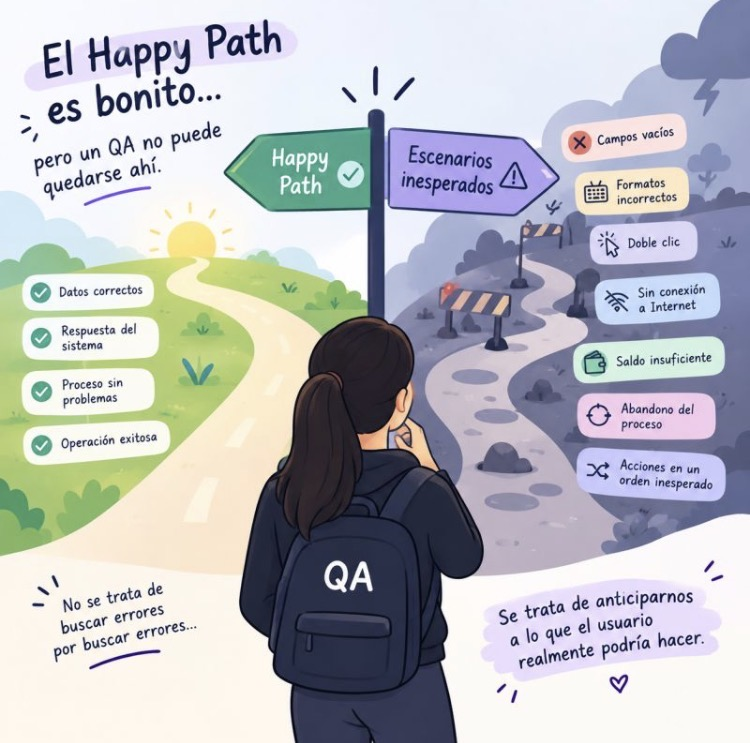

## Locators

* Es un fragmento de código que identifica cualquier elemento web en una página
* Son el componente fundamental de las pruebas
* Lenguajes de consulta DOM más utilizados: XPath y CSS Selector. Ambos localizan nodos HTML
* [Locating Elements](https://selenium-python.readthedocs.io/locating-elements.html)

### HTML

* Lenguaje de marcado que se utiliza para el desarrollo de páginas web
* Permite estructurar el texto de los documentos de forma jerárquica
* Se basa en etiquetas que determinan cómo debe mostrarse el texto y los atributos que pueden tomar dichas etiquetas

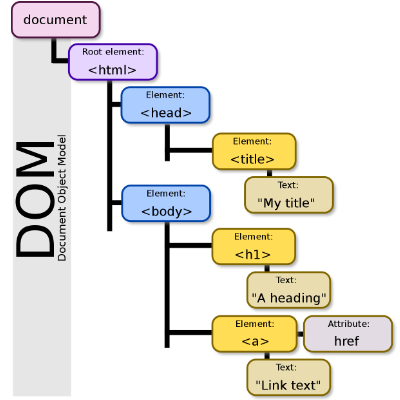

* Su sintáxis está basada en etiquetas: una de apertura y una de cierre. Y dentro de ellas va el contenido

    ```html
    <etiqueta>Contenido</etiqueta>
    ```

* Las etiquetas pueden contener información adicional indicada con atributos. Los atributos tienen un nombre y un valor

    ```html
    <etiqueta atributo="valor">Contenido</etiqueta>
    ```

### XPath

* XML Path Language
* Es un lenguaje que permite construir expresiones que recorren y procesan un documento XML
* Permite buscar y seleccionar la ubicación de cualquier elemento en una página web utilizando la estructura HTML
* [Xpath cheatsheet](https://devhints.io/xpath)

### Uso

1. Chrome
1. Fn + F12 -> Solapa 'Elementos' -> CTRL + F

### Formato básico

```xpath
//tagname[@attribute='value']
```

* **//**: selecciona el nodo actual
* **tagname**: tagname del nodo en particular, como input, div, img, etc.
* **@**: seleccionar atributo
* **attribute**: nombre del atributo del nodo, como id, name, class, etc.
* **value**: valor del atributo

### Tipos XPath

* **Absoluto**:
    * Utiliza la ruta completa desde el elemento raíz hasta el elemento deseado
    * Es la forma directa de encontrar el elemento, pero la desventaja es que si se realizan cambios en la ruta del elemento, XPath falla
    * Ejemplo:

```html
/html/body/main/div/div/div/div/div[1]/div/form/div/input
```

* **Relativo**:
    * Puede buscar elementos en cualquier parte de la página web, lo que significa que no es necesario escribir un xpath largo y puede comenzar desde el medio de la estructura HTML DOM
  * Siempre se prefiere el Xpath relativo, ya que no es una ruta completa desde el elemento raíz
  * Ejemplo:

```html
//*[@id="F1:username"]
```

### Ejemplos XPath

|                       | Ejemplos                                               |
| --                    | --                                                     |
| **básico**            | ```//input[@type='text']```                            |
| **contains**          | ```//*[contains(@name,'btn')]```                       |
| **or**                | ```//*[@type='submit' or @name='btnReset']```          |
| **and**               | ```//input[@type='submit' and @name='btnLogin']```     |
| **starts-with**       | ```//label[starts-with(@id,'message')]```              |
| **text**              | ```//td[text()='UserID']```                            |
| **not**               | ```//h1[not(contains(text(),'Facturador'))]```         |
| **last**              | ```//input[@type='text'])[last()]```                   |
| **following**         | ```//*[@type='text']//following::input```              |
| **ancestor**          | ```//*[texto()='Prueba empresarial']//ancestor::div``` |
| **child**             | ```//*[@id='java_technologies']//child::li```          |
| **preceding**         | ```//*[@type='submit']//preceding::input```            |
| **following-sibling** | ```//*[@type='submit']//following-sibling::input```    |
| **parent**            | ```//*[@id='rt-característica']//parent::div```        |
| **self**              | ```//*[@type='contraseña']//self::input```             |
| **descendant**        | ```//*[@id='rt-feature']//descendant::a```             |

### Estrategias de selección de elementos web

* Se recomienda usar el siguiente orden como criterio de uso de las estrategias:
    1. ID
    2. NAME
    3. XPATH
    4. CLASS_NAME
    5. TAG_NAME
    6. CSS_SELECTOR
    7. LINK_TEXT
    8. PARTIAL_LINK_TEXT

### Ejemplo de uso

* Se toma como ejemplo al campo de texto del login de AFIP

    ```html
    <input id="F1:username" name="F1:username" class="form-control" maxlength="11" size="11" type="number">
    ```

In [ ]:
driver.find_element(By.ID, 'F1:username')
driver.find_element(By.NAME, 'F1:username')
driver.find_element(By.XPATH, "//*[@id='F1:username']")
driver.find_element(By.CLASS_NAME, 'form-control')
driver.find_element(By.TAG_NAME, 'input')
driver.find_element(By.CSS_SELECTOR, '#F1:username')

* Se toma como ejemplo el link '¿Olvidaste tu clave?'

    ```html
    <a href="https://www.afip.gob.ar/claveFiscal/informacion-basica/recupero.asp" class="text-black" target="_blank">¿Olvidaste tu clave?</a>
    ```

In [ ]:
driver.find_element(By.LINK_TEXT, '¿Olvidaste tu clave?')
driver.find_element(By.PARTIAL_LINK_TEXT, '¿Olvidaste')

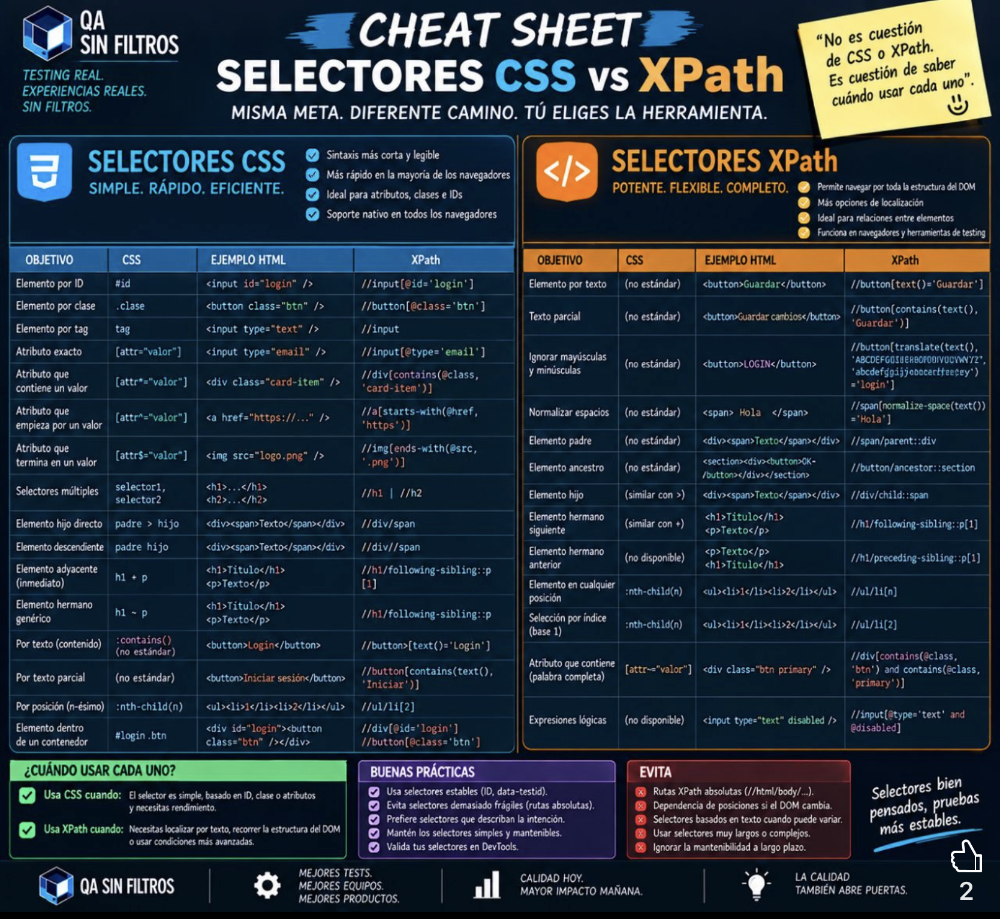

### Ejemplo: obtener título de la página

In [5]:
from selenium import webdriver

driver = webdriver.Chrome()

driver.get('https://www.google.com')

assert driver.title == 'Google'

driver.quit()

### Ejemplo: escribir en un campo de texto

In [18]:
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By

driver = webdriver.Chrome()

driver.get('https://www.python.org')

elem = driver.find_element(By.NAME, 'q')
elem.clear()
elem.send_keys('pycon')
elem.send_keys(Keys.RETURN)

assert 'No results found.' not in driver.page_source

driver.close()

### Ejemplo: clic en un enlace

In [19]:
from selenium import webdriver
from selenium.webdriver.common.by import By

driver = webdriver.Chrome()

driver.get('http://www.python.org') 

driver.find_element(By.LINK_TEXT, 'Docs').click()

assert driver.find_element(By.TAG_NAME, "h1").text == "Python 3.14.7 documentation"

driver.close()

## Waits

* La mayoría de las aplicaciones web se desarrollan utilizando Ajax y JavaScript
* Cuando una página es cargada por el navegador, los elementos con los que se quiere interactuar pueden cargarse a intervalos de tiempo diferentes
* No sólo hace que esto sea difícil de identificar el elemento, sino también si el elemento no está situado, se producirá una excepción **ElementNotVisibleException** 
* Usando las esperas, se puede resolver este problema
* La ventaja de estos tipos de espera es que si el webdriver encuentra al elemento en cuestión antes del tiempo de espera máximo, segurá con el flujo de ejecución y no "penalizará" con el tiempo restante de espera
* [Waits](https://selenium-python.readthedocs.io/waits.html)

### time.sleep(n)

* Método de la librería time de python
* Útil para realizar esperas en el código de forma que le dé tiempo al browser para terminar de cargar la página o encontrar un elemento por ejemplo
* Recibe como argumento un número entero que expresa la cantidad de segundos que se van a esperar
* Usado al momento de necesitar hacer una prueba durante el desarrollo de los test automatizados, pero no es una práctica recomendable
* Detiene el hilo de ejecución del programa que se está ejecutando y reanuda su ejecución una vez pasado el tiempo seteado
* Ejemplo: se espera 1 segundo antes de hacer click en el botón "Ingresar"

In [ ]:
import time

time.sleep(1)
driver.find_element(By.XPATH,"//*[@id='F1:btnIngresar']").click()

### Implicit wait

* Se utiliza para establecer el tiempo de espera predeterminado en todo el programa
* Implicit Wait le dirá al WebDriver que espere cierta cantidad de tiempo antes de que lance una excepción de **NoSuchElementException**
* Configuración predeterminada es 0
* Una vez que configurado el tiempo, el WebDriver esperará ese tiempo antes de lanzar una excepción

In [ ]:
driver = Firefox()
driver.implicitly_wait(10)
driver.get("http://somedomain/url_that_delays_loading")
my_dynamic_element = driver.find_element(By.ID, "myDynamicElement")

### Explicit wait

* Se utiliza para establecer el tiempo de espera para solo una instancia en particular
* Explicit Wait le dirá al WebDriver que espere ciertas condiciones (Expected Conditions) o el tiempo máximo excedido antes de lanzar una excepción **ElementNotVisibleException**
* Explicit Wait es un tipo inteligente de espera, pero sólo se puede aplicar para los elementos especificados
* La espera explícita ofrece mejores opciones que la de una espera implícita, ya que esperará los elementos Ajax cargados dinámicamente
* El siguiente ejemplo Selenium va a esperar por un máximo de 5 segundos a un elemento que coincida con un criterio dado.
* Si el elemento no se encuentra durante ese tiempo, se lanza una excepción de tiempo de espera (TimeoutException)
* Por default el webdriver llama a las ExpectedConditions cada 500 milisegundos hasta que devuelva True en caso de éxito o False en caso de no encontrarlo
* [Expected Conditions](https://selenium-python.readthedocs.io/waits.html)

In [ ]:
from selenium.webdriver.support import expected_conditions as ec
from selenium.webdriver.support.wait import WebDriverWait

wait = WebDriverWait(driver, 10)
element = wait.until(ec.element_to_be_clickable((By.ID, 'someid')))

## POM

### Definición

* Page Object Model
* Patrón de diseño para automatizar pruebas
* Patrón de diseño: dado un problema y un contexto, un patrón plantea una solución común aplicable a muchos proyectos

### Diseño monolítico vs POM

* Solución: separar interacción con el sitio de la lógica del test
* Test <-> Page (1 page por cada página del sitio)
* Las páginas web se representan como clases y los elementos web se definen como variables en la clase

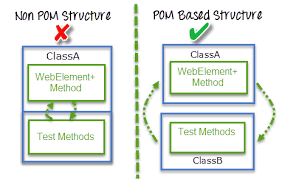

### Arquitectura

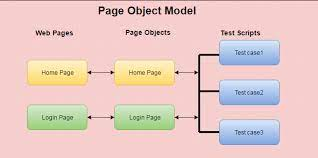

### Ventajas

* (+) Cohesión y (-) acoplamiento: el test unicamente debe encargarse de especificar el flujo que seguiria un caso de prueba y realizar las validaciones pertinentes
* Reduce la duplicidad de código
* Facilita el mantenimiento de código
* Hace que el código sea fácil de leer
* Optimiza los tests

### Ejemplo POM

In [1]:
%%file ui/page_login.py
from selenium.webdriver.common.by import By

class PageLogin:

    INPUT_USERNAME = (By.ID, 'username')
    INPUT_PASSWORD = (By.ID, 'password')
    BUTTON_LOGIN =   (By.TAG_NAME, 'button')

    def __init__(self, driver):
        self.driver = driver

    def get_input_username(self):
        return self.driver.find_element(*self.INPUT_USERNAME)

    def get_input_password(self):
        return self.driver.find_element(*self.INPUT_PASSWORD)

    def get_button_login(self):
        return self.driver.find_element(*self.BUTTON_LOGIN)

    def write_username(self, username):
        self.get_input_username().send_keys(username)

    def write_password(self, password):
        self.get_input_password().send_keys(password)

    def click_login(self):
        self.get_button_login().click()

Writing ui/page_login.py


In [2]:
%%file ui/page_secure.py
from selenium.webdriver.common.by import By

class PageSecure:

    H2_MSG = (By.TAG_NAME, 'h2')

    def __init__(self, driver):
        self.driver = driver

    def get_h2_msg(self):
        return self.driver.find_element(*self.H2_MSG)

    def text_msg(self):
        return self.get_h2_msg().text

Writing ui/page_secure.py


In [11]:
%%file ui/test_login.py
import pytest
from selenium import webdriver
from ui.page_login import PageLogin
from ui.page_secure import PageSecure

@pytest.fixture
def driver():
    driver = webdriver.Chrome()
    driver.get('https://the-internet.herokuapp.com/login')
    yield driver
    driver.quit()

@pytest.fixture
def class_setup(driver):
    page_login = PageLogin(driver)
    page_secure = PageSecure(driver)
    return page_login, page_secure

class TestLogin:
    
    def test_login(self, class_setup):
        page_login, page_secure = class_setup
        page_login.write_username('tomsmith')
        page_login.write_password('SuperSecretPassword!')
        page_login.click_login()
        assert page_secure.text_msg() == 'Secure Area'

Overwriting ui/test_login.py


In [12]:
!pytest ui/test_login.py

============================= test session starts ==============================
platform darwin -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0
rootdir: /Users/ppando/Materias/qa/doc
plugins: allure-pytest-2.16.0, Faker-37.3.0, mock-3.14.1, typeguard-4.4.4, anyio-4.2.0
collected 1 item                                                               

ui/test_login.py .                                                       [100%]

============================== 1 passed in 8.28s ===============================


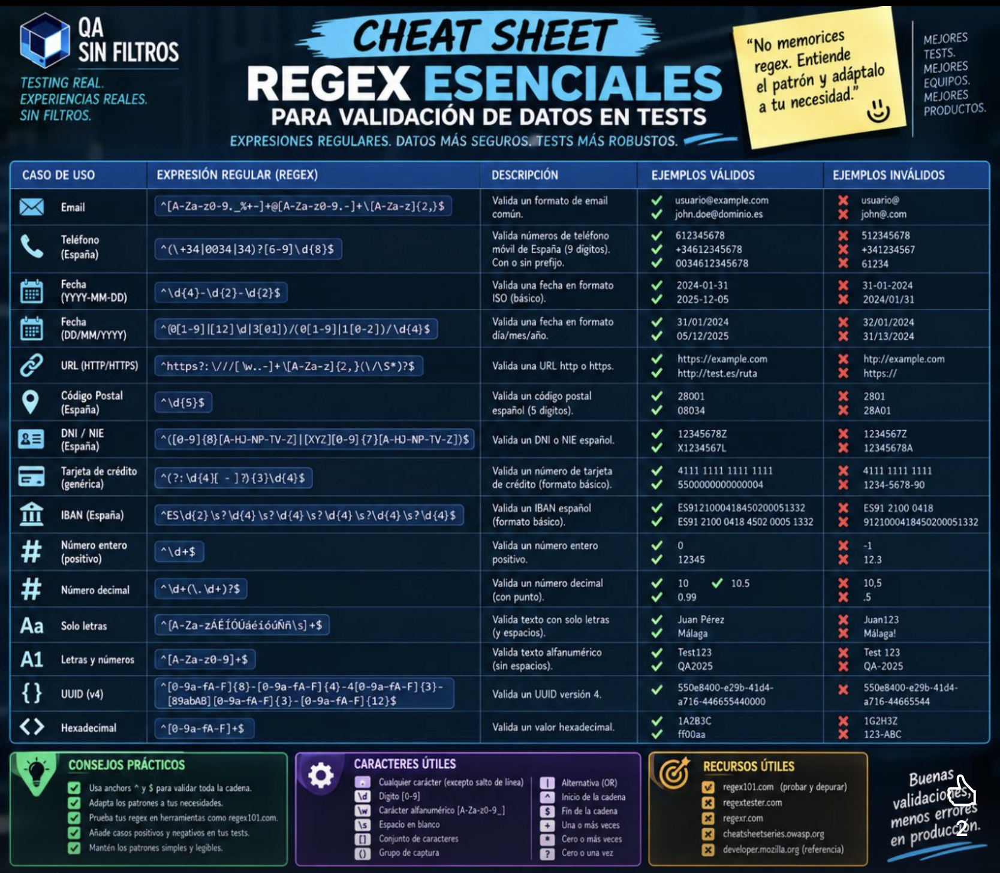

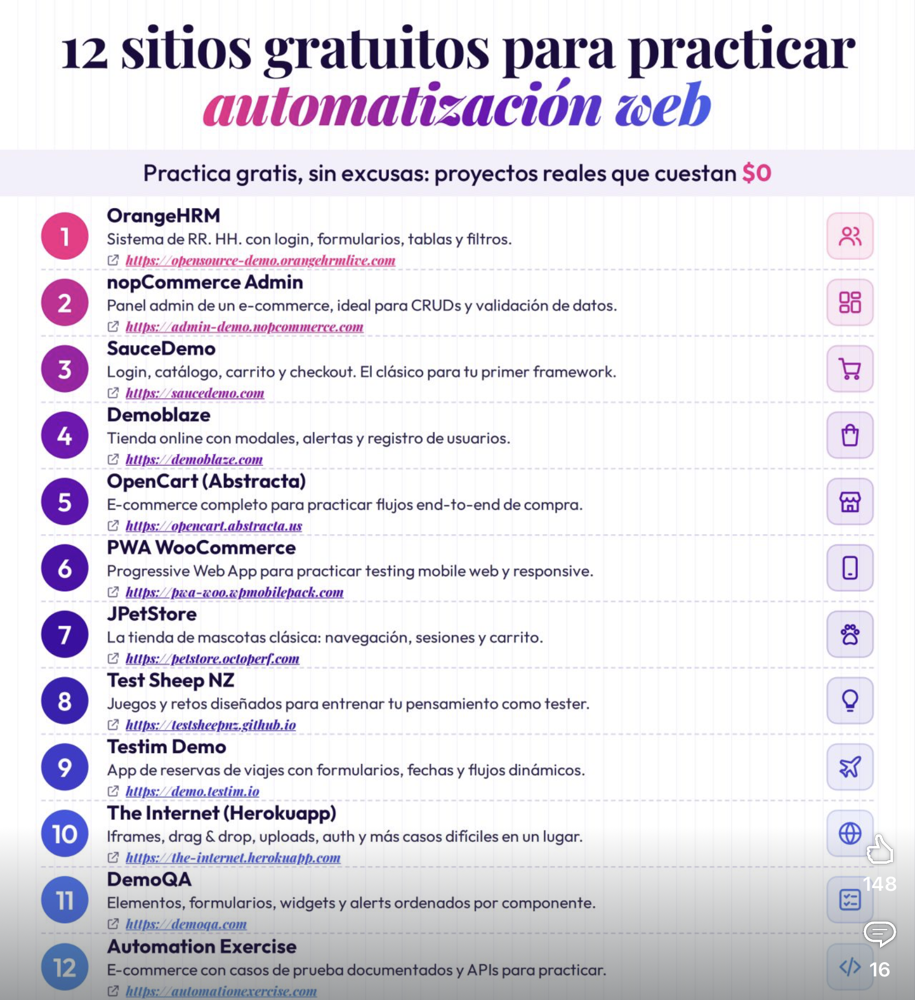

## Otros sitios

1. 𝗣𝗿𝗮𝗰𝘁𝗶𝗰𝗲 𝗧𝗲𝘀𝘁 𝗔𝘂𝘁𝗼𝗺𝗮𝘁𝗶𝗼𝗻 (https://practicetestautomation.com/)
    * login y validaciones
2. 𝗧𝗵𝗲 𝗜𝗻𝘁𝗲𝗿𝗻𝗲𝘁 (https://the-internet.herokuapp.com/)
    * alerts, waits, drag & drop
3. 𝗧𝗲𝘀𝘁𝗶𝗻𝗴 𝗔𝗿𝗲𝗻𝗮 (https://automationtesting.co.uk/)
    * formularios y tablas
4. 𝗗𝗲𝗺𝗼𝗤𝗔 (https://demoqa.com/)
    * UI dinámica (React)
5. 𝗦𝗮𝘂𝗰𝗲𝗗𝗲𝗺𝗼 (https://www.saucedemo.com/)
    * login + carrito
6. 𝗖𝗲𝗻𝘁𝘆𝗰 𝗣𝗿𝗮́𝗰𝘁𝗶𝗰𝗮 𝗘𝗰𝗼𝗺𝗺𝗲𝗿𝗰𝗲 (https://centyc.cl/practica/)
    * ecommerce completo para pruebas end-to-end, desde el login hasta la confirmación de compra. (Ideal para flujos reales y validaciones complejas)
7. 𝗧𝗲𝘀𝘁𝗶𝗺 𝗗𝗲𝗺𝗼 (https://demo.testim.io/)
    * login y flujos de reserva
8. **ToolsQA** (https://www.toolsqa.com/)
9. **Techlistic** (https://www.techlistic.com/)
10. **Examples Cypress** (https://example.cypress.io/)
11. **Coffee cart** (https://coffee-cart.app/)
12. **Otras** (https://qarmy.ar/webs-practicas-testing/)